## Data


In [1]:
from poe import PortfolioOptimizationEnv
from utils import Utils
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from stockstats import wrap

# For not having unwanted errors
plt.rcParams["font.family"] = "DejaVu Sans"

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
df = pd.read_csv('./data/features_panel.csv')
df.info()
df = wrap(df)

<class 'pandas.DataFrame'>
RangeIndex: 250900 entries, 0 to 250899
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   date              250900 non-null  str    
 1   tic               250900 non-null  str    
 2   close             250900 non-null  float64
 3   volume            250900 non-null  int64  
 4   rsi_6             250900 non-null  float64
 5   stochrsi_3        250900 non-null  float64
 6   volatility        250900 non-null  float64
 7   macd_stad         250900 non-null  float64
 8   macds_stad        250900 non-null  float64
 9   tema_stad         250900 non-null  float64
 10  pvo_stad          250900 non-null  float64
 11  pvos_stad         250900 non-null  float64
 12  pvoh_stad         250900 non-null  float64
 13  log-ret_stad      250900 non-null  float64
 14  adx_scale         250900 non-null  float64
 15  pdi_scale         250900 non-null  float64
 16  ndi_scale         250900 non-nu

In [3]:
features = df.copy()
features = features.reset_index()
features.info()


<class 'stockstats.StockDataFrame'>
RangeIndex: 250900 entries, 0 to 250899
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   date              250900 non-null  str    
 1   tic               250900 non-null  str    
 2   close             250900 non-null  float64
 3   volume            250900 non-null  int64  
 4   rsi_6             250900 non-null  float64
 5   stochrsi_3        250900 non-null  float64
 6   volatility        250900 non-null  float64
 7   macd_stad         250900 non-null  float64
 8   macds_stad        250900 non-null  float64
 9   tema_stad         250900 non-null  float64
 10  pvo_stad          250900 non-null  float64
 11  pvos_stad         250900 non-null  float64
 12  pvoh_stad         250900 non-null  float64
 13  log-ret_stad      250900 non-null  float64
 14  adx_scale         250900 non-null  float64
 15  pdi_scale         250900 non-null  float64
 16  ndi_scale         2509

In [4]:
TRAIN_WINDOW = 1000 # sessions
TEST_WINDOW = 200 # sessions

train, test = Utils.train_test_split(features, TRAIN_WINDOW, TEST_WINDOW)
test.reset_index(inplace=True, drop=True)
train.reset_index(inplace=True, drop=True)

In [5]:
train.dropna(inplace=True)
train.columns

Index(['date', 'tic', 'close', 'volume', 'rsi_6', 'stochrsi_3', 'volatility',
       'macd_stad', 'macds_stad', 'tema_stad', 'pvo_stad', 'pvos_stad',
       'pvoh_stad', 'log-ret_stad', 'adx_scale', 'pdi_scale', 'ndi_scale',
       'macd_signal', 'rsi_signal', 'adx_signal', 'cci_signal',
       'macd_signal_held', 'rsi_signal_held', 'adx_signal_held',
       'cci_signal_held'],
      dtype='str')

In [6]:
FEATURE_LIST = [
    "close",
    "volume",
    "rsi_6",
    "macd_stad",
    "macds_stad",
    "adx_scale",
    "pvo_stad",
    "tema_stad",
    "stochrsi_3",
    "log-ret_stad",
]


In [7]:
env = PortfolioOptimizationEnv(
    df = features,
    initial_amount = 10000,
    order_df = True,
    comission_fee_pct=0.001,
    comission_fee_model="trf",
    features = FEATURE_LIST,
)

Normalizing ['close', 'volume', 'rsi_6', 'macd_stad', 'macds_stad', 'adx_scale', 'pvo_stad', 'tema_stad', 'stochrsi_3', 'log-ret_stad'] by previous time...


## Equal-weight portfolio


In [8]:
# Equal Weight Portfolio
def equal_weight_portfolio(env):
    n = env._stock_dim
    weights = np.zeros(n + 1, dtype=np.float32)
    weights[1:] = 1/n
    weights /= weights.sum()
    rewards = []

    while True:
        obs, reward, terminated, truncated, info = env.step(weights)
        rewards.append(reward)
        if terminated:
            break
    
    return rewards

In [9]:
ew_train_env = PortfolioOptimizationEnv(
    df=train,
    initial_amount=10000,
    order_df=True,
    comission_fee_pct=0.001,
    comission_fee_model="trf",
    features=FEATURE_LIST,
    return_last_action=True,
    normalize_df=None,  # type: ignore[arg-type]
)


In [10]:
equal_weight_portfolio_rewards = equal_weight_portfolio(ew_train_env)


Initial portfolio value:10000
Final portfolio value: 23781.015625
Final accumulative portfolio value: 2.3781015872955322
Maximum DrawDown: -0.1830794536435596
Sharpe ratio: 1.7308334700962642


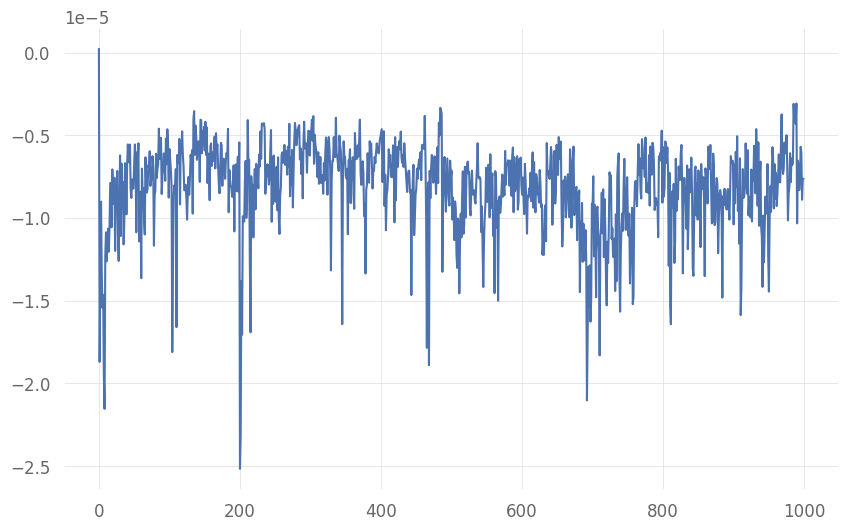

In [11]:
plt.plot(equal_weight_portfolio_rewards) # daily log returns

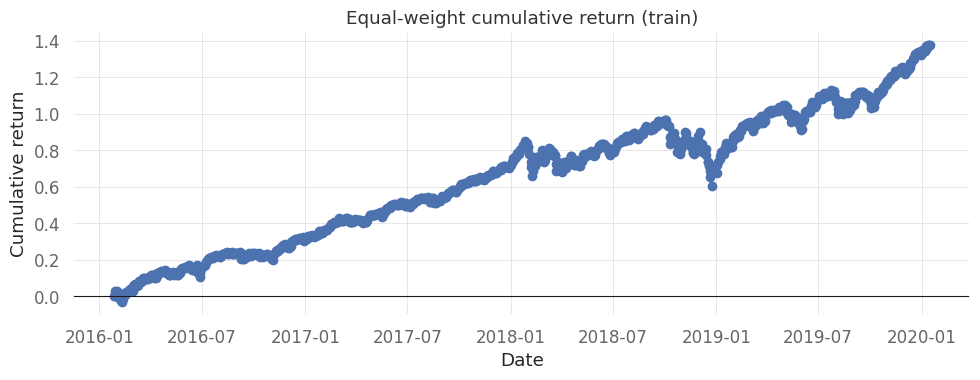

In [12]:
values = np.asarray(ew_train_env._asset_memory["final"], dtype=float)
dates = pd.to_datetime(ew_train_env._date_memory)
cumulative = values / values[0] - 1
plt.figure(figsize=(10, 4))
plt.plot(dates, cumulative, marker="o")
plt.axhline(0, color="k", lw=0.8)
plt.title("Equal-weight cumulative return (train)")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.tight_layout()
plt.show()


Equal-weight cumulative return on the training window.


In [13]:
ew_test_env = PortfolioOptimizationEnv(
    df=test,
    initial_amount=10000,
    order_df=True,
    comission_fee_pct=0.001,
    comission_fee_model="trf",
    features=FEATURE_LIST,
    return_last_action=True,
    normalize_df=None,  # type: ignore[arg-type]
)

rewards = equal_weight_portfolio(ew_test_env)


Initial portfolio value:10000
Final portfolio value: 10249.4716796875
Final accumulative portfolio value: 1.024947166442871
Maximum DrawDown: -0.3344544230109767
Sharpe ratio: 0.2753648545293451


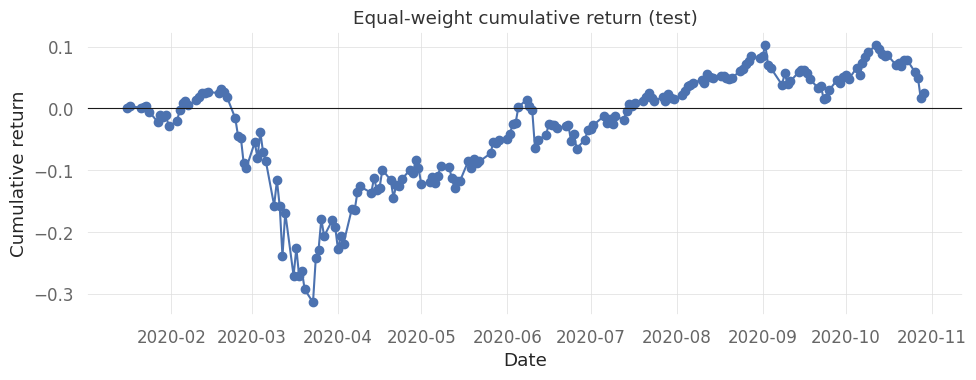

In [14]:
ew_values = np.asarray(ew_test_env._asset_memory["final"], dtype=float)
ew_dates = pd.to_datetime(ew_test_env._date_memory)
ew_cumulative = ew_values / ew_values[0] - 1
plt.figure(figsize=(10, 4))
plt.plot(ew_dates, ew_cumulative, marker="o")
plt.axhline(0, color="k", lw=0.8)
plt.title("Equal-weight cumulative return (test)")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.tight_layout()
plt.show()


## PPO


In [15]:
# Testing First RL Model
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

In [16]:
train.describe()

,close,volume,rsi_6,stochrsi_3,volatility,macd_stad,macds_stad,tema_stad,pvo_stad,pvos_stad,...,pdi_scale,ndi_scale,macd_signal,rsi_signal,adx_signal,cci_signal,macd_signal_held,rsi_signal_held,adx_signal_held,cci_signal_held
count,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000
mean,105.005685,1.715621e+07,55.141195,53.155566,0.014093,-0.045010,-0.048638,-0.822394,-0.010187,-0.010137,...,0.411796,0.379512,0.014660,0.122810,0.133970,0.24037,0.036040,0.062640,0.212050,0.896240
std,127.950051,5.332842e+07,18.250554,45.985391,0.006787,0.523215,0.522618,0.506023,0.085140,0.066393,...,0.157822,0.157677,0.726451,0.737491,0.688583,0.45613,0.998795,0.996688,0.974225,0.423646
min,0.805635,0.000000e+00,0.000000,0.000000,0.000339,-3.078307,-3.036608,-2.968217,-0.510175,-0.421522,...,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.00000,-1.000000,-1.000000,-1.000000,-1.000000
25%,41.590950,2.324101e+06,42.104329,0.000000,0.009687,-0.312047,-0.321316,-1.133473,-0.066450,-0.054123,...,0.299277,0.266415,-1.000000,0.000000,0.000000,0.00000,-1.000000,-1.000000,-1.000000,1.000000
50%,71.901440,4.727444e+06,56.018830,63.245821,0.012577,-0.054608,-0.061599,-0.857091,-0.019480,-0.014691,...,0.403213,0.367703,0.000000,0.000000,0.000000,0.00000,1.000000,1.000000,1.000000,1.000000
75%,135.965224,1.279680e+07,68.863892,100.000000,0.016647,0.246741,0.245634,-0.587985,0.035096,0.027437,...,0.513817,0.480810,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000
max,1425.671411,2.828708e+09,100.000000,100.000000,0.150291,2.858812,2.838601,2.822844,0.734543,0.519800,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000


In [17]:
ppo_train_env = PortfolioOptimizationEnv(
    df=train,
    initial_amount=10000,
    order_df=True,
    comission_fee_pct=0.001,
    comission_fee_model="trf",
    features=FEATURE_LIST,
    return_last_action=True,
    normalize_df=None,  # type: ignore[arg-type]
)


In [18]:
obs, info = ppo_train_env.reset()
state = obs["state"] if isinstance(obs, dict) else obs

print(ppo_train_env.observation_space)
print("state", state.shape, state.dtype)
print("features", ppo_train_env._features)
print("date", info["end_time"])

frame = pd.DataFrame(
    state[:, :, -1],
    index=ppo_train_env._features,
    columns=list(ppo_train_env._tic_list),
).T
print(frame.describe().T)
print(frame.iloc[:5, :5])
print("nan", np.isnan(state).sum(), "inf", np.isinf(state).sum())


Dict('last_action': Box(0.0, 1.0, (101,), float32), 'state': Box(-inf, inf, (10, 100, 1), float32))
state (10, 100, 1) float32
features ['close', 'volume', 'rsi_6', 'macd_stad', 'macds_stad', 'adx_scale', 'pvo_stad', 'tema_stad', 'stochrsi_3', 'log-ret_stad']
date 2016-01-27 00:00:00
              count          mean           std            min           25%  \
close         100.0  6.862730e+01  7.732187e+01       0.905939  2.708895e+01   
volume        100.0  2.423820e+07  7.211567e+07  745626.000000  3.874745e+06   
rsi_6         100.0  5.379250e+01  3.715407e+01       0.000000  2.007380e+01   
macd_stad     100.0 -1.929062e-01  8.701809e-02      -0.362539 -2.575548e-01   
macds_stad    100.0 -2.050179e-01  9.172720e-02      -0.391398 -2.765555e-01   
adx_scale     100.0  7.651062e-01  1.723143e-01       0.409187  6.026468e-01   
pvo_stad      100.0  3.693492e-03  1.208047e-02      -0.030515 -3.934853e-03   
tema_stad     100.0 -1.360195e+00  4.485793e-01      -2.628263 -1.589152e+0

In [ ]:
import optuna
from stable_baselines3.common.vec_env import VecNormalize

def rollout_value(model, df):
    env = PortfolioOptimizationEnv(
        df=df,
        initial_amount=10000,
        order_df=True,
        comission_fee_pct=0.001,
        comission_fee_model="trf",
        features=FEATURE_LIST,
        return_last_action=True,
        normalize_df=None,  # type: ignore[arg-type]
    )
    vec_env, obs = env.get_sb_env()
    value = float(env._initial_amount)
    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _ = vec_env.step(action)
        if done[0]:
            break
        value = float(env._portfolio_value)
    return value

best_ppo = {"model": None, "score": -np.inf}

def objective_ppo(trial):
    n_steps = trial.suggest_categorical("n_steps", [512, 1024, 2048])
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256, 512])
    gamma = trial.suggest_float("gamma", 0.9, 0.999)
    trial_env = PortfolioOptimizationEnv(
        df=train,
        initial_amount=10000,
        order_df=True,
        comission_fee_pct=0.001,
        comission_fee_model="trf",
        features=FEATURE_LIST,
        return_last_action=True,
        normalize_df=None,  # type: ignore[arg-type]
    )
    vec_env, _ = trial_env.get_sb_env()
    vec_env = VecNormalize(vec_env, norm_obs=False, norm_reward=True, clip_reward=10.0, gamma=gamma)
    model = PPO(
        "MultiInputPolicy",
        vec_env,
        verbose=0,
        seed=42,
        n_steps=n_steps,
        batch_size=batch_size,
        clip_range=trial.suggest_float("clip_range", 0.1, 0.3),
        gamma=gamma,
        tensorboard_log="./tb_ppo/",
        device="cpu",
        learning_rate=trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True),
        policy_kwargs=dict(log_std_init=trial.suggest_float("log_std_init", -2.0, 0.0)),
    )
    model.learn(total_timesteps=10000, tb_log_name="ppo")
    score = rollout_value(model, train)
    if score > best_ppo["score"]:
        best_ppo["model"] = model
        best_ppo["score"] = score
    return score

study_ppo = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_ppo.optimize(objective_ppo, n_trials=10)
model_ppo = best_ppo["model"]
model_ppo.save("ppo_portfolio")
print(study_ppo.best_params, best_ppo["score"])


[I 2026-09-26 02:29:02,536] A new study created in memory with name: no-name-418abe3d-cb28-4a63-90b2-821833a971b0
/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 21833.01171875
Final accumulative portfolio value: 2.1833012104034424
Maximum DrawDown: -0.1838627468058096
Sharpe ratio: 1.580582277243488
Initial portfolio value:10000
Final portfolio value: 21847.837890625
Final accumulative portfolio value: 2.184783697128296
Maximum DrawDown: -0.18461539436830887
Sharpe ratio: 1.5812835734146011
Initial portfolio value:10000
Final portfolio value: 21675.16015625
Final accumulative portfolio value: 2.167515993118286
Maximum DrawDown: -0.1859868524585171
Sharpe ratio: 1.5673097723782201
Initial portfolio value:10000
Final portfolio value: 21823.29296875
Final accumulative portfolio value: 2.1823291778564453
Maximum DrawDown: -0.1857016359380893
Sharpe ratio: 1.5799359559731425
Initial portfolio value:10000
Final portfolio value: 21777.361328125
Final accumulative portfolio value: 2.1777360439300537
Maximum DrawDown: -0.1848987582711008
Sharpe ratio: 1.5771291024637302
Initial portfolio value:10000


/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 23279.5234375
Final accumulative portfolio value: 2.3279523849487305
Maximum DrawDown: -0.18153265723420153
Sharpe ratio: 1.705567855404399


[I 2026-09-26 02:40:15,129] Trial 0 finished with value: 23279.5234375 and parameters: {'n_steps': 1024, 'batch_size': 64, 'gamma': 0.9857514384317185, 'clip_range': 0.22022300234864176, 'learning_rate': 0.0002607024758370766, 'log_std_init': -1.958831011408395}. Best is trial 0 with value: 23279.5234375.
/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 21319.654296875
Final accumulative portfolio value: 2.131965398788452
Maximum DrawDown: -0.1847066497895441
Sharpe ratio: 1.5343619657182805
Initial portfolio value:10000
Final portfolio value: 21325.181640625
Final accumulative portfolio value: 2.1325180530548096
Maximum DrawDown: -0.18560251630695912
Sharpe ratio: 1.534027728616729
Initial portfolio value:10000
Final portfolio value: 21140.560546875
Final accumulative portfolio value: 2.11405611038208
Maximum DrawDown: -0.187479543934575
Sharpe ratio: 1.5189733712345315
Initial portfolio value:10000
Final portfolio value: 21333.57421875
Final accumulative portfolio value: 2.133357524871826
Maximum DrawDown: -0.18752836644857496
Sharpe ratio: 1.5359928414243782
Initial portfolio value:10000
Final portfolio value: 21272.443359375
Final accumulative portfolio value: 2.127244234085083
Maximum DrawDown: -0.18616330902911582
Sharpe ratio: 1.5312028060231309
Initial portfolio value:10000


/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 23555.08203125
Final accumulative portfolio value: 2.3555080890655518
Maximum DrawDown: -0.18136138443731598
Sharpe ratio: 1.7274893836154397


[I 2026-09-26 02:51:58,411] Trial 1 finished with value: 23555.08203125 and parameters: {'n_steps': 512, 'batch_size': 512, 'gamma': 0.9427625568455694, 'clip_range': 0.15824582803960838, 'learning_rate': 0.00016738085788752134, 'log_std_init': -1.7210122786959163}. Best is trial 1 with value: 23555.08203125.
/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 21656.72265625
Final accumulative portfolio value: 2.1656723022460938
Maximum DrawDown: -0.18413312381215297
Sharpe ratio: 1.5647963623969028
Initial portfolio value:10000
Final portfolio value: 21660.193359375
Final accumulative portfolio value: 2.1660194396972656
Maximum DrawDown: -0.18491526852208773
Sharpe ratio: 1.5643107734925374
Initial portfolio value:10000
Final portfolio value: 21498.23828125
Final accumulative portfolio value: 2.1498239040374756
Maximum DrawDown: -0.18658716131622277
Sharpe ratio: 1.5514221211146744
Initial portfolio value:10000
Final portfolio value: 21637.927734375
Final accumulative portfolio value: 2.163792848587036
Maximum DrawDown: -0.18644319088101113
Sharpe ratio: 1.5636987775061832
Initial portfolio value:10000
Final portfolio value: 21590.875
Final accumulative portfolio value: 2.1590874195098877
Maximum DrawDown: -0.18547556676743593
Sharpe ratio: 1.5602429437238363
Initial portfolio value:10000

/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 11558.2919921875
Final accumulative portfolio value: 1.1558291912078857
Maximum DrawDown: -0.29169833409125223
Sharpe ratio: 0.6861929318576807


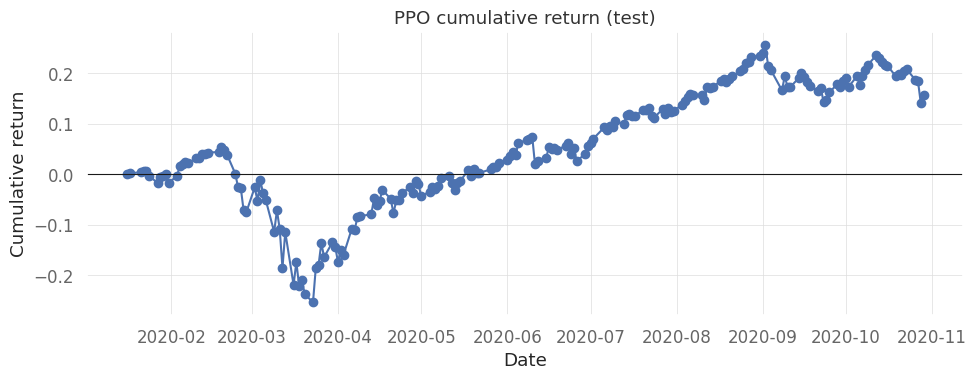

In [ ]:
ppo_test_env = PortfolioOptimizationEnv(
    df=test,
    initial_amount=10000,
    order_df=True,
    comission_fee_pct=0.001,
    comission_fee_model="trf",
    features=FEATURE_LIST,
    return_last_action=True,
    normalize_df=None,  # type: ignore[arg-type]
)
env_test, obs = ppo_test_env.get_sb_env()

values, dates = (
    list(ppo_test_env._asset_memory["final"]),
    list(ppo_test_env._date_memory),
)
while True:
    action, _ = model_ppo.predict(obs, deterministic=True)
    obs, reward, done, info = env_test.step(action)
    if done[0]:
        break
    values = list(ppo_test_env._asset_memory["final"])
    dates = list(ppo_test_env._date_memory)
values = np.asarray(values, dtype=float)
dates = pd.to_datetime(dates)
cumulative = values / values[0] - 1

plt.figure(figsize=(10, 4))
plt.plot(dates, cumulative, marker="o")
plt.axhline(0, color="k", lw=0.8)
plt.title("PPO cumulative return (test)")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.tight_layout()
plt.show()


/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 15925.671875
Final accumulative portfolio value: 1.5925672054290771
Maximum DrawDown: -0.16007456865421477
Sharpe ratio: 1.733222064445817
Initial portfolio value:10000
Final portfolio value: 16191.0634765625
Final accumulative portfolio value: 1.6191062927246094
Maximum DrawDown: -0.16583647798037782
Sharpe ratio: 1.731235575282915


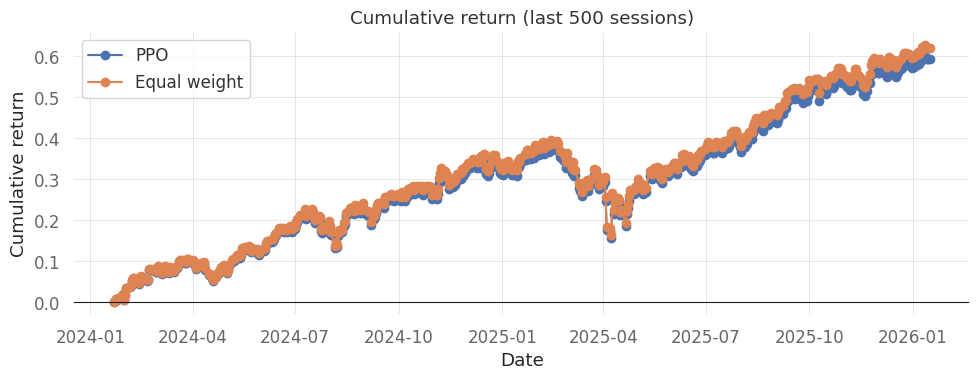

In [ ]:
sessions = pd.Index(pd.to_datetime(features["date"]).unique()).sort_values()
recent = features[pd.to_datetime(features["date"]).isin(sessions[-500:])]
recent = pd.DataFrame(recent).reset_index()
ppo_recent_env = PortfolioOptimizationEnv(
    df=recent,
    initial_amount=10000,
    order_df=True,
    comission_fee_pct=0.001,
    comission_fee_model="trf",
    features=FEATURE_LIST,
    return_last_action=True,
    normalize_df=None,  # type: ignore[arg-type]
)
env_test, obs = ppo_recent_env.get_sb_env()

values, dates = (
    list(ppo_recent_env._asset_memory["final"]),
    list(ppo_recent_env._date_memory),
)
while True:
    action, _ = model_ppo.predict(obs, deterministic=True)
    obs, reward, done, info = env_test.step(action)
    if done[0]:
        break
    values = list(ppo_recent_env._asset_memory["final"])
    dates = list(ppo_recent_env._date_memory)
values = np.asarray(values, dtype=float)
dates = pd.to_datetime(dates)
cumulative = values / values[0] - 1

ew_recent_env = PortfolioOptimizationEnv(
    df=recent,
    initial_amount=10000,
    order_df=True,
    comission_fee_pct=0.001,
    comission_fee_model="trf",
    features=FEATURE_LIST,
    return_last_action=True,
    normalize_df=None,  # type: ignore[arg-type]
)
_ = equal_weight_portfolio(ew_recent_env)
ew_values = np.asarray(ew_recent_env._asset_memory["final"], dtype=float)
ew_dates = pd.to_datetime(ew_recent_env._date_memory)
ew_cumulative = ew_values / ew_values[0] - 1
plt.figure(figsize=(10, 4))
plt.plot(dates, cumulative, marker="o", label="PPO")
plt.plot(ew_dates, ew_cumulative, marker="o", label="Equal weight")
plt.axhline(0, color="k", lw=0.8)
plt.title("Cumulative return (last 500 sessions)")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.legend()
plt.tight_layout()
plt.show()


## DDPG


In [ ]:
ddpg_train_env = PortfolioOptimizationEnv(
    df=train,
    initial_amount=10000,
    order_df=True,
    comission_fee_pct=0.001,
    comission_fee_model="trf",
    features=FEATURE_LIST,
    return_last_action=True,
    normalize_df=None,  # type: ignore[arg-type]
)

from stable_baselines3 import DDPG
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.vec_env import VecNormalize
import optuna

n_actions = ddpg_train_env.action_space.shape[-1]
best_ddpg = {"model": None, "score": -np.inf}

def objective_ddpg(trial):
    gamma = trial.suggest_float("gamma", 0.95, 0.999)
    sigma = trial.suggest_float("sigma", 0.05, 0.2)
    action_noise = NormalActionNoise(
        mean=np.zeros(n_actions),
        sigma=sigma * np.ones(n_actions),
    )
    trial_env = PortfolioOptimizationEnv(
        df=train,
        initial_amount=10000,
        order_df=True,
        comission_fee_pct=0.001,
        comission_fee_model="trf",
        features=FEATURE_LIST,
        return_last_action=True,
        normalize_df=None,  # type: ignore[arg-type]
    )
    vec_env, _ = trial_env.get_sb_env()
    vec_env = VecNormalize(vec_env, norm_obs=False, norm_reward=True, clip_reward=10.0, gamma=gamma)
    model = DDPG(
        "MultiInputPolicy",
        vec_env,
        verbose=0,
        seed=42,
        learning_rate=trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True),
        buffer_size=100_000,
        learning_starts=trial.suggest_categorical("learning_starts", [500, 1000, 2000]),
        tau=trial.suggest_float("tau", 1e-3, 1e-2, log=True),
        gamma=gamma,
        train_freq=1,
        gradient_steps=1,
        batch_size=trial.suggest_categorical("batch_size", [64, 128, 256]),
        tensorboard_log="./tb_ddpg/",
        device="cuda",
        action_noise=action_noise,
    )
    model.learn(total_timesteps=25000, tb_log_name="ddpg")
    score = rollout_value(model, train)
    if score > best_ddpg["score"]:
        best_ddpg["model"] = model
        best_ddpg["score"] = score
    return score

study_ddpg = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_ddpg.optimize(objective_ddpg, n_trials=10)
model_ddpg = best_ddpg["model"]
model_ddpg.save("ddpg_portfolio")
print(study_ddpg.best_params, best_ddpg["score"])


[I 2026-09-26 01:45:31,148] A new study created in memory with name: no-name-d8eee708-438f-4e3d-8ef9-461f215b7391
/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 21568.11328125
Final accumulative portfolio value: 2.156811237335205
Maximum DrawDown: -0.15921331451006582
Sharpe ratio: 1.4959652336931557
Initial portfolio value:10000
Final portfolio value: 23807.123046875
Final accumulative portfolio value: 2.3807122707366943
Maximum DrawDown: -0.15958861796080193
Sharpe ratio: 1.6583663424080974
Initial portfolio value:10000
Final portfolio value: 23617.71484375
Final accumulative portfolio value: 2.361771583557129
Maximum DrawDown: -0.15967705723297165
Sharpe ratio: 1.640599655221226
Initial portfolio value:10000
Final portfolio value: 23668.54296875
Final accumulative portfolio value: 2.366854190826416
Maximum DrawDown: -0.15649541811071432
Sharpe ratio: 1.645790802609757
Initial portfolio value:10000
Final portfolio value: 23808.326171875
Final accumulative portfolio value: 2.3808326721191406
Maximum DrawDown: -0.15988856752220992
Sharpe ratio: 1.6551899606925227
Initial portfolio value:1000

/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 24577.6875
Final accumulative portfolio value: 2.457768678665161
Maximum DrawDown: -0.15717867394353124
Sharpe ratio: 1.7081679187594767


[I 2026-09-26 01:55:04,372] Trial 0 finished with value: 24577.6875 and parameters: {'gamma': 0.9683524658235207, 'sigma': 0.19260714596148742, 'learning_rate': 0.000291063591313307, 'learning_starts': 500, 'tau': 0.001143098387631322, 'batch_size': 64}. Best is trial 0 with value: 24577.6875.
/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


...

Initial portfolio value:10000
Final portfolio value: 18539.431640625
Final accumulative portfolio value: 1.853943109512329
Maximum DrawDown: -0.1812824108802713
Sharpe ratio: 1.2539209512446943
Initial portfolio value:10000
Final portfolio value: 18366.25
Final accumulative portfolio value: 1.8366249799728394
Maximum DrawDown: -0.18485050516189905
Sharpe ratio: 1.2344170653146045
Initial portfolio value:10000
Final portfolio value: 24363.0546875
Final accumulative portfolio value: 2.436305522918701
Maximum DrawDown: -0.15737184725447073
Sharpe ratio: 1.6942124222517305
Initial portfolio value:10000
Final portfolio value: 24312.697265625
Final accumulative portfolio value: 2.431269645690918
Maximum DrawDown: -0.15746399615628415
Sharpe ratio: 1.690900616374851
Initial portfolio value:10000
Final portfolio value: 24406.9375
Final accumulative portfolio value: 2.4406938552856445
Maximum DrawDown: -0.15831595708572377
Sharpe ratio: 1.6975292351411857
Initial portfolio value:10000
Final por

/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 24577.6875
Final accumulative portfolio value: 2.457768678665161
Maximum DrawDown: -0.15717867394353124
Sharpe ratio: 1.7081679187594767


[I 2026-09-26 02:15:07,630] Trial 2 finished with value: 24577.6875 and parameters: {'gamma': 0.9799807918413965, 'sigma': 0.07092407909780628, 'learning_rate': 3.8396292998041685e-05, 'learning_starts': 2000, 'tau': 0.0015837031559118749, 'batch_size': 128}. Best is trial 0 with value: 24577.6875.
/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 18540.51171875
Final accumulative portfolio value: 1.854051113128662
Maximum DrawDown: -0.1812854740725377
Sharpe ratio: 1.254050451770665
Initial portfolio value:10000
Final portfolio value: 24310.4765625
Final accumulative portfolio value: 2.4310476779937744
Maximum DrawDown: -0.15751300915704858
Sharpe ratio: 1.6916612460363507
Initial portfolio value:10000
Final portfolio value: 24313.228515625
Final accumulative portfolio value: 2.4313228130340576
Maximum DrawDown: -0.15750598720723408
Sharpe ratio: 1.691188292425831
Initial portfolio value:10000
Final portfolio value: 24419.666015625
Final accumulative portfolio value: 2.4419665336608887
Maximum DrawDown: -0.15734200565332113
Sharpe ratio: 1.6997239415105245
Initial portfolio value:10000
Final portfolio value: 24328.486328125
Final accumulative portfolio value: 2.4328486919403076
Maximum DrawDown: -0.15805981271616365
Sharpe ratio: 1.692253457625471
Initial portfolio value:1000

In [ ]:
def test_function(model, df, title):
    env = PortfolioOptimizationEnv(
        df=df,
        initial_amount=10000,
        order_df=True,
        comission_fee_pct=0.001,
        comission_fee_model="trf",
        features=FEATURE_LIST,
        normalize_df=None,  # type: ignore[arg-type]
        return_last_action=True,
    )

    env_test, obs = env.get_sb_env()
    values, dates = (
        list(env._asset_memory["final"]),
        list(env._date_memory),
    )
    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, info = env_test.step(action)
        if done[0]:
            break
        values = list(env._asset_memory["final"])
        dates = list(env._date_memory)
    
    values = np.asarray(values, dtype=float)
    dates = pd.to_datetime(dates)
    cumulative = values / values[0] - 1

    plt.figure(figsize=(10, 4))
    plt.plot(dates, cumulative, marker="o")
    plt.axhline(0, color="k", lw=0.8)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Cumulative return")
    plt.tight_layout()
    plt.show()

In [ ]:
ddpg_test_env = PortfolioOptimizationEnv(
    df=test,
    initial_amount=10000,
    order_df=True,
    comission_fee_pct=0.001,
    comission_fee_model="trf",
    features=FEATURE_LIST,
    return_last_action=True,
    normalize_df=None,  # type: ignore[arg-type]
)
env_test, obs = ddpg_test_env.get_sb_env()

values, dates = (
    list(ddpg_test_env._asset_memory["final"]),
    list(ddpg_test_env._date_memory),
)
while True:
    action, _ = model_ddpg.predict(obs, deterministic=True)
    obs, reward, done, info = env_test.step(action)
    if done[0]:
        break
    values = list(ddpg_test_env._asset_memory["final"])
    dates = list(ddpg_test_env._date_memory)
values = np.asarray(values, dtype=float)
dates = pd.to_datetime(dates)
cumulative = values / values[0] - 1

plt.figure(figsize=(10, 4))
plt.plot(dates, cumulative, marker="o")
plt.axhline(0, color="k", lw=0.8)
plt.title("DDPG cumulative return (test)")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.tight_layout()
plt.show()


In [ ]:
sessions = pd.Index(pd.to_datetime(features["date"]).unique()).sort_values()
recent = features[pd.to_datetime(features["date"]).isin(sessions[-500:])]
recent = pd.DataFrame(recent).reset_index()

ddpg_recent_env = PortfolioOptimizationEnv(
    df=recent,
    initial_amount=10000,
    order_df=True,
    comission_fee_pct=0.001,
    comission_fee_model="trf",
    features=FEATURE_LIST,
    return_last_action=True,
    normalize_df=None,  # type: ignore[arg-type]
)
env_test, obs = ddpg_recent_env.get_sb_env()

values, dates = (
    list(ddpg_recent_env._asset_memory["final"]),
    list(ddpg_recent_env._date_memory),
)
while True:
    action, _ = model_ddpg.predict(obs, deterministic=True)
    obs, reward, done, info = env_test.step(action)
    if done[0]:
        break
    values = list(ddpg_recent_env._asset_memory["final"])
    dates = list(ddpg_recent_env._date_memory)
values = np.asarray(values, dtype=float)
dates = pd.to_datetime(dates)
cumulative = values / values[0] - 1

ew_recent_env = PortfolioOptimizationEnv(
    df=recent,
    initial_amount=10000,
    order_df=True,
    comission_fee_pct=0.001,
    comission_fee_model="trf",
    features=FEATURE_LIST,
    return_last_action=True,
    normalize_df=None,  # type: ignore[arg-type]
)
_ = equal_weight_portfolio(ew_recent_env)
ew_values = np.asarray(ew_recent_env._asset_memory["final"], dtype=float)
ew_dates = pd.to_datetime(ew_recent_env._date_memory)
ew_cumulative = ew_values / ew_values[0] - 1
plt.figure(figsize=(10, 4))
plt.plot(dates, cumulative, marker="o", label="DDPG")
plt.plot(ew_dates, ew_cumulative, marker="o", label="Equal weight")
plt.axhline(0, color="k", lw=0.8)
plt.title("Cumulative return (last 500 sessions)")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.legend()
plt.tight_layout()
plt.show()


## Strategy comparison


In [ ]:
def portfolio_curve(env):
    values = np.asarray(env._asset_memory["final"], dtype=float)
    dates = pd.to_datetime(env._date_memory)
    return dates, values / values[0] - 1

def equal_weight_curve(df):
    env = PortfolioOptimizationEnv(
        df=df,
        initial_amount=10000,
        order_df=True,
        comission_fee_pct=0.001,
        comission_fee_model="trf",
        features=FEATURE_LIST,
        return_last_action=True,
        normalize_df=None,  # type: ignore[arg-type]
    )
    equal_weight_portfolio(env)
    return portfolio_curve(env)

def policy_curve(model, df):
    env = PortfolioOptimizationEnv(
        df=df,
        initial_amount=10000,
        order_df=True,
        comission_fee_pct=0.001,
        comission_fee_model="trf",
        features=FEATURE_LIST,
        return_last_action=True,
        normalize_df=None,  # type: ignore[arg-type]
    )
    vec_env, obs = env.get_sb_env()
    values = list(env._asset_memory["final"])
    dates = list(env._date_memory)
    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _ = vec_env.step(action)
        if done[0]:
            break
        values = list(env._asset_memory["final"])
        dates = list(env._date_memory)
    values = np.asarray(values, dtype=float)
    return pd.to_datetime(dates), values / values[0] - 1

sessions = pd.Index(pd.to_datetime(features["date"]).unique()).sort_values()
recent = features[pd.to_datetime(features["date"]).isin(sessions[-500:])].copy()
recent = pd.DataFrame(recent).reset_index()

windows = (
    ("Test window", test),
    ("Last 500 sessions", recent),
)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, (title, df) in zip(axes, windows):
    span = pd.to_datetime(df["date"])
    curves = (
        ("Equal weight",) + equal_weight_curve(df),
        ("PPO",) + policy_curve(model_ppo, df),
        ("DDPG",) + policy_curve(model_ddpg, df),
    )
    for label, dates, cumulative in curves:
        ax.plot(dates, cumulative, marker="o", label=label)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_title(f"{title}\n{span.min():%Y-%m-%d} to {span.max():%Y-%m-%d}")
    ax.set_xlabel("Date")
    ax.legend()
axes[0].set_ylabel("Cumulative return")
fig.tight_layout()
plt.show()
